<a href="https://colab.research.google.com/github/sanchitasontakke07-exe/Day16-Insurance_dataset/blob/main/Day16(insurance).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [7]:
data=pd.read_csv("./insurance.csv")
print(data)

      age     sex   bmi  children smoker     region  expenses
0      19  female  27.9         0    yes  southwest  16884.92
1      18    male  33.8         1     no  southeast   1725.55
2      28    male  33.0         3     no  southeast   4449.46
3      33    male  22.7         0     no  northwest  21984.47
4      32    male  28.9         0     no  northwest   3866.86
...   ...     ...   ...       ...    ...        ...       ...
1333   50    male  31.0         3     no  northwest  10600.55
1334   18  female  31.9         0     no  northeast   2205.98
1335   18  female  36.9         0     no  southeast   1629.83
1336   21  female  25.8         0     no  southwest   2007.95
1337   61  female  29.1         0    yes  northwest  29141.36

[1338 rows x 7 columns]


In [8]:
data.head(10)

,age,sex,bmi,children,smoker,region,expenses
0,19,female,27.9,0,yes,southwest,16884.92
1,18,male,33.8,1,no,southeast,1725.55
2,28,male,33.0,3,no,southeast,4449.46
3,33,male,22.7,0,no,northwest,21984.47
4,32,male,28.9,0,no,northwest,3866.86
5,31,female,25.7,0,no,southeast,3756.62
6,46,female,33.4,1,no,southeast,8240.59
7,37,female,27.7,3,no,northwest,7281.51
8,37,male,29.8,2,no,northeast,6406.41
9,60,female,25.8,0,no,northwest,28923.14


In [9]:
data.shape

(1338, 7)

In [10]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   expenses  1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [11]:
data.describe()

,age,bmi,children,expenses
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.665471,1.094918,13270.422414
std,14.049960,6.098382,1.205493,12110.011240
min,18.000000,16.000000,0.000000,1121.870000
25%,27.000000,26.300000,0.000000,4740.287500
50%,39.000000,30.400000,1.000000,9382.030000
75%,51.000000,34.700000,2.000000,16639.915000
max,64.000000,53.100000,5.000000,63770.430000


In [12]:
data.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
expenses,0


In [16]:
numerical = data.select_dtypes(include='number').columns
categorical = data.select_dtypes(exclude='number').columns

print("Numerical Columns:", numerical)
print("Categorical Columns:", categorical)

Numerical Columns: Index(['age', 'bmi', 'children', 'expenses'], dtype='object')
Categorical Columns: Index(['sex', 'smoker', 'region'], dtype='object')


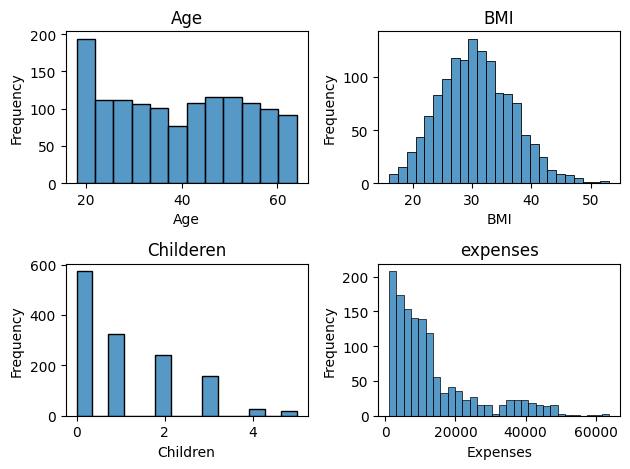

In [33]:
import seaborn as sns
plt.subplot(2,2,1)
sns.histplot(data["age"])
plt.title("Age")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.subplot(2,2,2)
sns.histplot(data['bmi'])
plt.title("BMI")
plt.xlabel("BMI")
plt.ylabel("Frequency")


plt.subplot(2,2,3)
sns.histplot(data["children"])
plt.title("Childeren")
plt.xlabel("Children")
plt.ylabel("Frequency")


plt.subplot(2,2,4)
sns.histplot(data["expenses"])
plt.title("expenses")
plt.xlabel("Expenses")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()



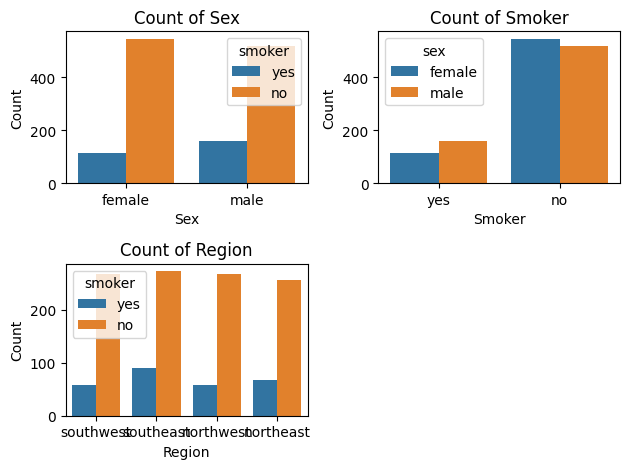

In [70]:
plt.subplot(2,2,1)
sns.countplot(x="sex", hue="smoker", data=data)
plt.title("Count of Sex")
plt.xlabel("Sex")
plt.ylabel("Count")
plt.subplot(2,2,2)
sns.countplot(x="smoker", hue="sex", data=data)
plt.title("Count of Smoker")
plt.xlabel("Smoker")
plt.ylabel("Count")
plt.subplot(2,2,3)
sns.countplot(x="region", hue="smoker", data=data)
plt.title("Count of Region")
plt.xlabel("Region")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

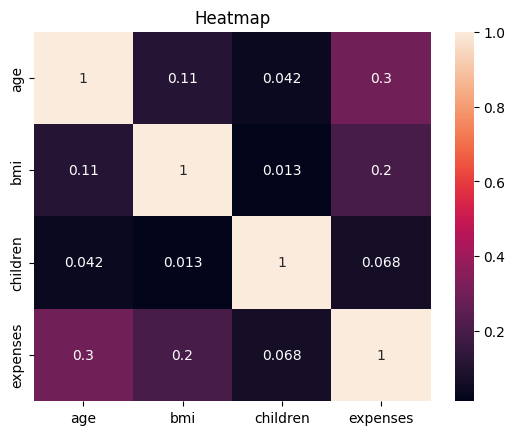

In [52]:
corr = data.corr(numeric_only=True)

sns.heatmap(corr, annot=True)
plt.title("Heatmap")
plt.show()

In [59]:
print("Mean:",data["expenses"].mean())
print("Maximum:",data["expenses"].max())
print("Minimum: ",data["expenses"].min())
print(data.groupby("smoker")["expenses"].mean())

Mean: 13270.422414050823
Maximum: 63770.43
Minimum:  1121.87
smoker
no      8434.268449
yes    32050.231971
Name: expenses, dtype: float64


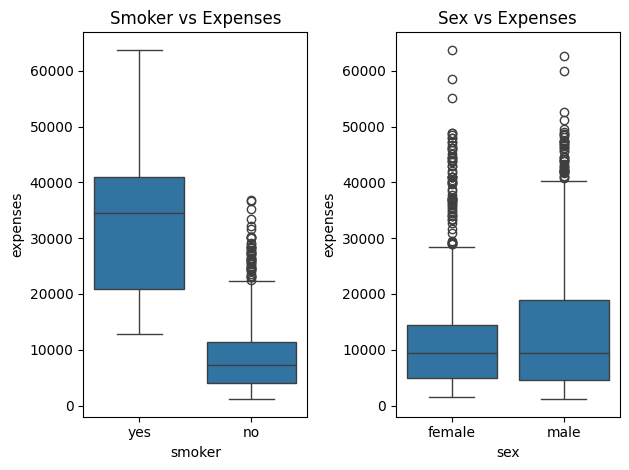

In [64]:
plt.subplot(1,2,1)
sns.boxplot(x="smoker", y="expenses", data=data)
plt.title("Smoker vs Expenses")
plt.subplot(1,2,2)
sns.boxplot(x="sex", y="expenses", data=data)
plt.title("Sex vs Expenses")
plt.tight_layout()
plt.show()

In [72]:
# 1.Average age and BMI
print("Average Age:", data["age"].mean())
print("Average BMI:", data["bmi"].mean())
# 2.Average insurance expenses of smokers and non-smokers
print("\nAverage Expenses by Smoker:")
print(data.groupby("smoker")["expenses"].mean())
# 3.Region with the highest number of customers
print("\nRegion with Highest Customers:")
print(data["region"].value_counts().idxmax())
# 4.Summary
# Average age is about 39 years.
# Average BMI is about 30.66.
# Smokers pay much higher insurance expenses than non-smokers.
# Southeast region has the highest number of customers.
# Most customers are non-smokers and have 0–2 children.

Average Age: 39.20702541106129
Average BMI: 30.66547085201794

Average Expenses by Smoker:
smoker
no      8434.268449
yes    32050.231971
Name: expenses, dtype: float64

Region with Highest Customers:
southeast
